In [2]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pickle as pkl

# python font no dingbattes
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

matplotlib.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams["font.sans-serif"] = ["Helvetica", "Arial", "DejaVu Sans"]  # fallback list

In [3]:
#Change working directory to the location of the script
os.chdir('/home/apoorva/Desktop/MZB-new-analysis')

In [8]:
df_new = pd.read_csv('data/new_data_MZB.csv')
df_ont = pd.read_csv('data/New_data/ontogeny_counts.csv')


file_path = 'data/emperical_fit_T1.pkl'
if os.path.getsize(file_path) > 0:
    with open(file_path, 'rb') as f:
        data_neutral = pkl.load(f)
else:
    raise EOFError("File is empty")

file_path = 'data/emperical_fit_T2.pkl'
if os.path.getsize(file_path) > 0:
    with open(file_path, 'rb') as f:
        data_T2 = pkl.load(f)
else:
    raise EOFError("File is empty")

file_path = 'data/emperical_fit_FO.pkl'
if os.path.getsize(file_path) > 0:
    with open(file_path, 'rb') as f:
        data_FO = pkl.load(f)
else:
    raise EOFError("File is empty")

file_path = 'data/New output (pkl)/Steady State/SHM/SHM_T1.pkl'
with open(file_path, 'rb') as f:
    data_neutral_T1 = pkl.load(f)
    
file_path = 'data/New output (pkl)/Steady State/SHM/SHM_T2.pkl'
with open(file_path, 'rb') as f:
    data_neutral_T2 = pkl.load(f)
    
# file_path = 'data/New output (pkl)/Steady State/SHM/SHM_FO.pkl'
# with open(file_path, 'rb') as f:
#     data_neutral_FO = pkl.load(f)

# file_path1 = '/home/apoorva/Desktop/work/MZ_analysis/data/New output (pkl)/Steady State/Spline_nt/SHM_T1_notransform.pkl'
# if os.path.getsize(file_path1) > 0:
#     with open(file_path1, 'rb') as f:
#         data_neutral_SHM = pkl.load(f)
# else:
#     raise EOFError("File is empty")

# file_path2 = '/home/apoorva/Desktop/work/MZ_analysis/data/New output (pkl)/Steady State/Spline_nt/TDM_T1_division_hill.pkl'
# if os.path.getsize(file_path2) > 0:
#     with open(file_path2, 'rb') as f:
#         data_neutral_TDD = pkl.load(f)
# else:
#     raise EOFError("File is empty")

# file_path3 = '/home/apoorva/Desktop/work/MZ_analysis/data/New output (pkl)/Steady State/Spline_nt/TDM_T1_influx.pkl'
# if os.path.getsize(file_path3) > 0:
#     with open(file_path3, 'rb') as f:
#         data_neutral_TDI = pkl.load(f)
# else:
#     raise EOFError("File is empty")

#Filter last row of the dataframe
df_new = df_new.iloc[:-1]
# df_new['agebin'] = pd.cut(df_new['Age at BMT'], bins=[0,70, 140], labels=['<10 weeks', '>10 weeks'])

print(df_new.head(10))
# print(df_ont.head(10))

                               Unnamed: 0  Age at BMT  Age at S1K  \
0  20181129_Bcells_SPLEEN_14d_001_019.fcs          74          88   
1  20181129_Bcells_SPLEEN_14d_002_020.fcs          41          88   
2      20181204_2-5wks_SPLEEN_001_018.fcs          74          92   
3      20181204_2-5wks_SPLEEN_002_019.fcs          41          59   
4        20181207_3wks_SPLEEN_001_048.fcs          74          95   
5        20181207_3wks_SPLEEN_002_049.fcs          41          62   
6        20181213_4wks_SPLEEN_001_024.fcs          74         102   
7        20181213_4wks_SPLEEN_002_025.fcs          41          69   
8   20181220_5wks_SPLEEN_CD1d_001_065.fcs          74         109   
9   20181220_5wks_SPLEEN_CD1d_002_066.fcs          41          76   

   Days postBMT  Lamis ID      total_FM     fd_FM  percent_total_ki67+_FM  \
0            14    832634  2.247009e+07  0.016125                8.243927   
1            14    848687  2.440681e+07  0.013667                7.994476   
2        

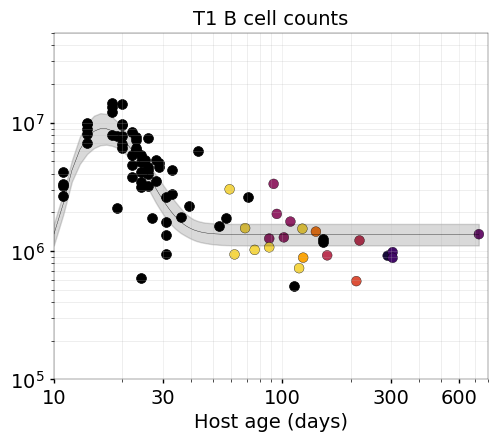

In [9]:
# global font size
sns.set_context("notebook", font_scale=1.3)
col_pal = sns.color_palette("inferno", n_colors=len(df_new['Age at BMT'].unique()))
col_pal = col_pal[::-1]

# Plot T1 AA4.1 counts
t_ev =np.array(np.arange(10,731,1))
fig = plt.figure(figsize=(5.6, 4.5))
# sns.scatterplot(data=df_new, x='Age at S1K', y='total_T1_AA4.1+',s=50, color = 'black', edgecolor='black', linewidth=0.5,legend=False)
sns.scatterplot(data=df_new, x='Age at S1K', y='total_T1_AA4.1+', hue='Age at BMT', palette=col_pal, s=50, edgecolor='black', linewidth=0.25, legend=False)

sns.scatterplot(data=df_ont, x='age.at.S1K', y='T1 AA4.1+_total', s=50, color = 'black', edgecolor='black', linewidth=0.5, legend=False)
# plt.axhline(y=1298783, color='grey', linestyle='--', label='Adult')
plt.plot(t_ev, np.mean(data_neutral.T1_counts_pred, axis=0), color= 'black',  linewidth=0.25)
plt.fill_between(t_ev, np.quantile(data_neutral.T1_counts_pred, 0.025, axis=0), np.quantile(data_neutral.T1_counts_pred, 0.975, axis=0), color = 'black', alpha=0.15)
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e5, 5*1e7)
plt.xlim(10, 800)
plt.xticks([10, 30,  100, 300, 600], [10, 30, 100, 300, 600])
plt.xlabel('Host age (days)', fontsize=14)
plt.title('T1 B cell counts', fontsize=14)
plt.ylabel('')
# Axis border width
for spine in plt.gca().spines.values():
    spine.set_linewidth(0.25)   # try 0.6 / 0.8 / 1.0

# Tick mark width
plt.tick_params(axis='both', which='both', width=0.8)
plt.grid(True, axis="x", ls="-.", color='silver', linewidth=0.25)
plt.grid(True, axis="y", ls="--", color='silver', linewidth=0.25)
plt.tick_params(axis="both", labelsize=14)

# tick mark size and thickness
plt.tick_params(axis="both", which="major", length=3, width=1)
plt.tick_params(axis="both", which="minor", length=2, width=0.5)
# no legend
plt.legend([],[], frameon=False)
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)


# save the figure
plt.savefig('T1_precursor.pdf', dpi=300)
plt.show()

In [ ]:
print(np.mean(data_neutral.theta_0))
print(np.mean(data_neutral.nu))
print(np.mean(data_neutral.n))

14.1076865
0.30780698874999995
1.9940437174999999


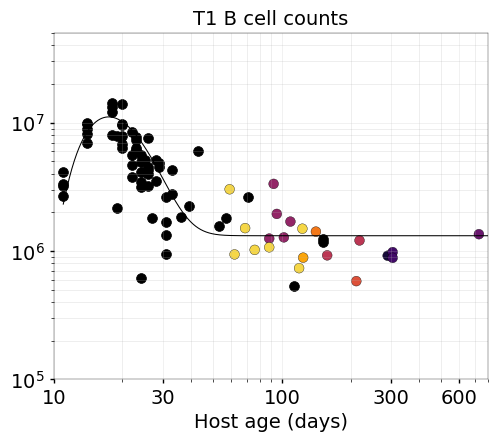

In [21]:
def P(t):
    theta_0 = np.exp(14.09)
    nu = 0.27
    n = 2
    # # return theta_0 * (1 + (t-11)**n * np.exp(-nu * (t-11)))
    # return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))
    # theta_0 = np.exp(14.12)
    # nu = 0.264
    # # n = 1.96
    # return theta_0 * (1 + (t-11)**n * np.exp(-nu * (t-11)))
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))
    

# Plot T1 AA4.1 counts

fig = plt.figure(figsize=(5.6, 4.5))
# sns.scatterplot(data=df_new, x='Age at S1K', y='total_T1_AA4.1+', alpha=0.85 ,s=85, color = 'black', legend=False)
sns.scatterplot(data=df_new, x='Age at S1K', y='total_T1_AA4.1+', hue='Age at BMT', palette=col_pal, s=50, edgecolor='black', linewidth=0.25, legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='T1 AA4.1+_total', s=50, color = 'black', edgecolor='black', linewidth=0.5, legend=False)
plt.plot(np.arange(11, 800, 0.05), P(np.arange(11, 800, 0.05)), color= 'black',  linewidth=0.75)
# plt.axhline(y=1298783, color='black', linestyle='--', linewidth=1)

plt.xscale('log')
plt.yscale('log')
plt.ylim(1e5, 5*1e7)
plt.xlim(10, 800)
plt.xticks([10, 30,  100, 300, 600], [10, 30, 100, 300, 600])
plt.xlabel('Host age (days)', fontsize=14)
plt.title('T1 B cell counts', fontsize=14)
plt.ylabel('')
# Axis border width
for spine in plt.gca().spines.values():
    spine.set_linewidth(0.25)   # try 0.6 / 0.8 / 1.0

# Tick mark width
plt.tick_params(axis='both', which='both', width=0.8)
plt.grid(True, axis="x", ls="-.", color='silver', linewidth=0.25)
plt.grid(True, axis="y", ls="--", color='silver', linewidth=0.25)
plt.tick_params(axis="both", labelsize=14)

# tick mark size and thickness
plt.tick_params(axis="both", which="major", length=3, width=1)
plt.tick_params(axis="both", which="minor", length=2, width=0.5)
# no legend
plt.legend([],[], frameon=False)
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)


# save the figure
plt.savefig('T1_precursor.pdf', dpi=300)
plt.show()


In [ ]:
def P(t):
    theta_0 = np.exp(np.mean(data_neutral.theta_0))
    nu = np.mean(data_neutral.nu)
    n = np.mean(data_neutral.n)
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))
   
 
# Define the ODE function
def ode_function_T1(t, M, phi, rho, delta, P):
    dMdt = phi * P(t) - (delta - rho) * M
    return np.array(dMdt)


# Define the parameters as array
phi = data_neutral_T1.stan_variable('phi')
rho = data_neutral_T1.stan_variable('rho')
M_stable = data_neutral_T1.stan_variable('MZ_counts_pred1')


delta = ((phi * 1298783) / M_stable[:,0] ) + rho


#Initial conditions at time t=40
M0 = [12058]


t_ev = np.arange(11, 750, 0.1)

sol = np.zeros((len(data_neutral_T1.phi), len(t_ev)))
for i in range(len(data_neutral_T1.phi)):
    result = solve_ivp(ode_function_T1, [11, 750], M0, t_eval= t_ev, args=(phi[i], rho[i], delta[i], P))
    sol[i, :] = result.y[0]

print(sol.shape)



KeyboardInterrupt: 

In [ ]:
def P1(t):
    theta_0 = np.exp(np.mean(data_T2.theta_0))
    nu = np.mean(data_T2.nu)
    n = np.mean(data_T2.n)
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))
   
 
# Define the ODE function
def ode_function_T2(t, M, phi, rho, delta, P1):
    dMdt = phi * P1(t) - (delta - rho) * M
    return np.array(dMdt)


# Define the parameters as array
phi = data_neutral_T2.stan_variable('phi')
rho = data_neutral_T2.stan_variable('rho')
M_stable = data_neutral_T2.stan_variable('MZ_counts_pred1')


delta = ((phi * 1308516) / M_stable[:,0] ) + rho


#Initial conditions at time t=40
M0 = [12058]


t_ev = np.arange(11, 750, 0.1)

solT2 = np.zeros((len(data_neutral_T2.phi), len(t_ev)))
for i in range(len(data_neutral_T2.phi)):
    result2 = solve_ivp(ode_function_T2, [11, 750], M0, t_eval= t_ev, args=(phi[i], rho[i], delta[i], P1))
    solT2[i, :] = result2.y[0]

print(solT2.shape)

(5000, 7390)


In [ ]:
# def P2(t):
#     theta_0 = np.exp(np.mean(data_FO.theta_0))
#     nu = np.mean(data_FO.nu)
#     t0 = np.mean(data_FO.t0)
#     return theta_0 / (1 + np.exp(-nu * (t - t0)))

# # # Define delta_func
# # def delta_func(t, phi, rho_val, P2, mz_counts):
# #     delta = ((phi * P2(t)) / mz_counts) + rho_val
# #     return delta

# # Define the ODE function
# def ode_function(t, M, phi, rho, delta, P1):
#     dMdt = phi * P2(t) - (delta - rho) * M
#     return np.array(dMdt)

# # Parameters
# phi = data_neutral_FO.stan_variable('phi')
# rho = data_neutral_FO.stan_variable('rho')
# mz_counts = data_neutral_FO.stan_variable('MZ_counts_pred1')[:,0]

# delta = ((phi * 27591715) / M_stable[:,0] ) + rho
# # M_stable = data_neutral_SHM.stan_variable('MZ_counts_pred1')

# # Initial conditions at time t=11
# M0 = [12058]

# t_ev = np.arange(11, 750, 0.1)

# solFO = np.zeros((len(data_neutral_FO.phi), len(t_ev)))
# for i in range(len(data_neutral_FO.phi)):
#     result3 = solve_ivp(ode_function, [11, 750], M0, t_eval= t_ev, args=(phi[i], rho[i], delta[i], P2))
#     solFO[i, :] = result3.y[0]

# print(solFO.shape)


In [ ]:
bmt_ages = np.array([41, 42, 51, 58, 65, 74, 87, 89, 101])
solve_times = np.array([59, 124, 141, 212, 158, 88, 731, 306, 291])

#Arrange solve time in increasing order
sorted_indices = np.argsort(solve_times)
bmt_ages = bmt_ages[sorted_indices]
solve_times = solve_times[sorted_indices]

print(solve_times)



In [ ]:
# 9 start times


n_draws = len(phi)
col_pal = sns.color_palette("inferno", n_colors=len(df_new['Age at BMT'].unique()))
col_pal = col_pal[::-1]

plt.figure(figsize=(5.6, 4.5))
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', s=60, color='black', edgecolor='black', linewidth=0.5, label='Young WT mice', legend=False)
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', hue='Age at BMT', palette=col_pal, s=60, edgecolor='black', linewidth=0.25, legend=False)

for j, st in enumerate(solve_times):

    # extrapolate from solve_time to 750
    t_post = np.arange(11, st, 1)
    y_post = np.zeros((n_draws, len(t_post)))

    for i in range(n_draws):
        res_post = solve_ivp(
            ode_function_T2,
            [11, st],
            M0,
            t_eval=t_post,
            args=(phi[i], rho[i], delta[i], P1)
        )
        y_post[i, :] = res_post.y[0]

    y_med = np.median(y_post, axis=0)
    y_lb = np.quantile(y_post, 0.025, axis=0)
    y_ub = np.quantile(y_post, 0.975, axis=0)

    plt.plot(t_post, y_med, color=col_pal[j], lw=0.25)
    plt.fill_between(t_post, y_lb, y_ub, color=col_pal[j], alpha=0.1)
    
for j, st in enumerate(solve_times):

    # extrapolate from solve_time to 750
    t_post_t1 = np.arange(11, st, 1)
    y_post_t1 = np.zeros((n_draws, len(t_post_t1)))

    for i in range(n_draws):
        res_post_t1 = solve_ivp(
            ode_function_T1,
            [11, st],
            M0,
            t_eval=t_post_t1,
            args=(phi[i], rho[i], delta[i], P)
        )
        y_post_t1[i, :] = res_post_t1.y[0]

    y_med = np.median(y_post_t1, axis=0)
    y_lb = np.quantile(y_post_t1, 0.025, axis=0)
    y_ub = np.quantile(y_post_t1, 0.975, axis=0)

    plt.plot(t_post_t1, y_med, color=col_pal[j], lw=0.25, ls='--')
    plt.fill_between(t_post_t1, y_lb, y_ub, color=col_pal[j], alpha=0.05)

# Axis border width
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.25)   # try 0.6 / 0.8 / 1.0
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(10, 800)
plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
plt.xlabel('Host age (days)')
plt.ylabel('')
plt.title('Predicted MZ counts for neonatal using parameters estimated from chimera fits in constant birth-loss model')
plt.grid(True, axis="x", ls="-.", color='silver', linewidth=0.25)
plt.grid(True, axis="y", ls="--", color='silver', linewidth=0.25)
plt.tick_params(axis="both", labelsize=14)

# tick mark size and thickness
plt.tick_params(axis="both", which="major", length=3, width=1)
plt.tick_params(axis="both", which="minor", length=3, width=0.5)
plt.legend([],[], frameon=False)
plt.tight_layout()
#save the figure
plt.savefig('figures/Ontogeny_predictions.pdf', dpi=300)

In [ ]:
# Plot the Mz counts
fig = plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', s=75, color= 'black',label='Young WT mice', legend=False, linewidth=0.5)
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', s=75, color= 'orange', label='Chimera', legend=False,  linewidth=0.5)

plt.plot(t_ev, np.mean(sol, axis=0), linestyle= 'dashed', color = 'orange', label = 'T1')
plt.plot(t_ev, np.mean(solT2, axis=0), color = 'orange', label = 'T2')
# plt.plot(t_ev, np.mean(solFO, axis=0), linestyle= 'dotted', color = 'steelblue', label = 'FO')
plt.fill_between(t_ev, np.quantile(sol, 0.025, axis=0), np.quantile(sol, 0.975, axis=0), color = 'orange',alpha=0.1, linestyle= 'dashed')
plt.fill_between(t_ev, np.quantile(solT2, 0.025, axis=0), np.quantile(solT2, 0.975, axis=0), color = 'orange',alpha=0.1)
# plt.fill_between(t_ev, np.quantile(solFO, 0.025, axis=0), np.quantile(solFO, 0.975, axis=0), color = 'steelblue',alpha=0.2, linestyle= 'dotted')

plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(10, 800)
plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
plt.xlabel('Host age (days)')
plt.ylabel('')
plt.title('Predicted MZ counts for neonatal using parameters estimated \n from chimera fits in constant birth-loss model')
plt.grid(True, axis="x", ls="-.", color='silver', linewidth=0.5)
plt.grid(True, axis="y", ls="--", color='silver', linewidth=0.5)
plt.legend(loc = 'lower right')
# plt.tight_layout()

#save the figure
# plt.savefig('/Users/apoorvasingh/Desktop/MZB-new-analysis/figures/Ontogeny_predictions.pdf', dpi=300)
plt.show()



In [ ]:
# Plot the Mz counts
fig = plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', s=75, color= 'black',label='Young WT mice', legend=False, linewidth=0.5)
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', s=75,  color= 'orange', label='Chimera', legend=False, linewidth=0.5)
plt.plot(t_ev, np.mean(solFO, axis=0), linestyle= 'dotted', color = 'orange', label = 'FO')
plt.fill_between(t_ev, np.quantile(solFO, 0.025, axis=0), np.quantile(solFO, 0.975, axis=0), color = 'orange',alpha=0.2, linestyle= 'dotted')

plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(10, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
plt.xlabel('Host age (days)')
plt.ylabel('')
plt.title('Predicted MZ counts for neonatal using parameters estimated \n from chimera fits in constant birth-loss model')
plt.grid(True, axis="x", ls="-.", color='silver', linewidth=0.5)
plt.grid(True, axis="y", ls="--", color='silver', linewidth=0.5)
plt.legend(loc = 'lower right')
# plt.tight_layout()

#save the figure
plt.savefig('/Users/apoorvasingh/Desktop/MZB-new-analysis/figures/Ontogeny_predictions_FO.pdf', dpi=300)
plt.show()

In [ ]:
def P(t):
    theta_0 = np.exp(np.mean(data_neutral.theta_0))
    nu = np.mean(data_neutral.nu)
    n = np.mean(data_neutral.n)
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))

def rho_func(t, rho_var, r_d_val):
    return rho_var / (1 + t/r_d_val) 


def delta_func(t, phi_val, rho_val, r_d_val, mz_counts_val):
    delta = ((phi_val * 1298783) / mz_counts_val) + (rho_val / (1 + t / r_d_val))
    return delta

# Define the ODE function
def ode_function(t, M, phi_val, rho_val, r_d_val, mz_counts_val, P):
    rho_t = rho_func(t, rho_val, r_d_val)
    delta_t = delta_func(t, phi_val, rho_val, r_d_val, mz_counts_val)
    dMdt = phi_val * P(t) - (delta_t - rho_t) * M
    return np.array(dMdt)

#Initial conditions at time t=11
M0 = [12058]

t_ev = np.arange(11, 750, 0.001)

phi = data_neutral_TDD.stan_variable('phi')  #Influx rate
rho_values = data_neutral_TDD.stan_variable('rho')  # Extract 'rho' values from CmdStanMCMC object
r_d_values = data_neutral_TDD.stan_variable('r_d')  # Extract 'r_d' values from CmdStanMCMC object
mz_counts = data_neutral_TDD.stan_variable('MZ_counts_pred1')[:,0]

sol1 = np.zeros((len(rho_values), len(t_ev)))
for i in range(len(rho_values)):
    result = solve_ivp(ode_function, [11, 750], M0, t_eval=t_ev,
                       args=(phi[i], rho_values[i], r_d_values[i], mz_counts[i], P))
    sol1[i, :] = result.y[0]




In [ ]:
# Plot the Mz counts
fig = plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=100, color= 'Red',label='Young WT mice', legend=False)
# plt.plot(t_ev, sol.y[0], label='Predicted trajectory')
plt.plot(t_ev, np.mean(sol1, axis=0))
plt.fill_between(t_ev, np.quantile(sol1, 0.025, axis=0), np.quantile(sol1, 0.975, axis=0), color = 'steelblue',alpha=0.2)
# plt.fill_between(t_ev, np.quantile(sol, 0.025, axis=0), np.quantile(sol, 0.975, axis=0), color = 'steelblue',alpha=0.2)
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 75, 100, 300, 600], [10, 30, 75, 100, 300, 600])
plt.xlabel('Host age (days)', fontsize=16)
plt.ylabel('')
plt.tick_params(axis='both', labelsize=15)
plt.title('Predicted MZ counts for neonatal using parameters estimated \n from chimera fits in age-dependent T1 division model')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Ontogeny predictions/TDM_division_T1.png', dpi=300)
plt.show()

In [ ]:
def P(t):
    theta_0 = np.exp(np.mean(data_neutral.theta_0))
    nu = np.mean(data_neutral.nu)
    n = np.mean(data_neutral.n)
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))

def phi_func(t, phi, r_d_val):
    return phi * np.exp(-r_d_val * (t-40))


def delta_func(t, phi, rho_val, r_d_val, mz_counts):
    delta = (((phi * np.exp(-r_d_val * (t-40))) * 1298783) / mz_counts) + rho_val
    return delta

# Define the ODE function
def ode_function(t, M, phi, rho_val, r_d_val, mz_counts, P):
    phi_t = phi_func(t, phi, r_d_val)
    delta_t = delta_func(t, phi_t, rho_val, r_d_val, mz_counts)
    dMdt = phi_t * P(t) - (delta_t - rho_val) * M
    return np.array(dMdt)

#Initial conditions at time t=11
M0 = [12058]

t_ev = np.arange(11, 750, 0.001)

phi = data_neutral_TDI.stan_variable('phi')  #Influx rate
rho_val = data_neutral_TDI.stan_variable('rho')  # Extract 'rho' values from CmdStanMCMC object
r_d_val = data_neutral_TDI.stan_variable('r_d')  # Extract 'r_d' values from CmdStanMCMC object
mz_counts = data_neutral_TDI.stan_variable('MZ_counts_pred1')[:,0]

sol2 = np.zeros((len(rho_val), len(t_ev)))
for i in range(len(rho_val)):
    result = solve_ivp(ode_function, [11, 750], M0, t_eval=t_ev,
                       args=(phi[i], rho_val[i], r_d_val[i], mz_counts[i], P))
    sol2[i, :] = result.y[0]


In [ ]:
# Plot the Mz counts
fig = plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=100, color= 'Red',label='Young WT mice', legend=False)
# plt.plot(t_ev, sol.y[0], label='Predicted trajectory')
plt.plot(t_ev, np.mean(sol2, axis=0))
plt.fill_between(t_ev, np.quantile(sol2, 0.025, axis=0), np.quantile(sol2, 0.975, axis=0), color = 'steelblue',alpha=0.2)
# plt.fill_between(t_ev, np.quantile(sol, 0.025, axis=0), np.quantile(sol, 0.975, axis=0), color = 'steelblue',alpha=0.2)
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 75, 100, 300, 600], [10, 30, 75, 100, 300, 600])
plt.xlabel('Host age (days)', fontsize=16)
plt.ylabel('')
plt.tick_params(axis='both', labelsize=15)
plt.title('Predicted MZ counts for neonatal using parameters estimated \n from chimera fits in age-dependent T1 influx model')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Ontogeny predictions/TDM_influx_T1.png', dpi=300)
plt.show()